# Advanced Physics - Advection, Diffusion & Sources

Real astrophysical environments are rarely just diffusion. In this tutorial, we will see how to combine multiple operators and add a continuous source of particles.

## 1. Setup

We will start with an empty (vacuum) state and see how it fills up from a source.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from saetass.grid import Grid
from saetass.state import State
from saetass.solver import Solver

# Spatial grid: 0 to 20 pc
grid = Grid.uniform(r_min=0.0, r_max=20.0, num_r_cells=200, t_min=0, t_max=2.0, num_timesteps=200)

# Empty initial state
state = State(f=np.zeros(grid.shape))

## 2. Defining a Complex Problem

We will now solve for:
1. **Advection**: Particles moving outwards due to a stellar wind.
2. **Diffusion**: Particles spreading out.
3. **Source**: A continuous injection of particles at the center ($r=0$).

Notice the `problem_type` string: the order of operators defines the operator splitting sequence.

In [5]:
# Combined problem type
problem_type = "advection-diffusion-source"

# Configuration for each operator
v_const = 5.0
v_centers = np.full(grid.num_cells_r, v_const)

D_const = 0.5
D_values = np.full(grid.num_cells_r, D_const)

# Define a source function: continuous injection at r=0
def continuous_source(r, p, t):
    q0 = 100.0
    sigma = 0.5
    return q0 * np.exp(-r**2 / (2 * sigma**2))

operator_params = {
    "advection": {
        "v_centers": v_centers,
        "limiter": "vanleer",   # Numerical limiter for stability
        "order": 2,              # Second-order accurate scheme
        "cfl": 0.5,              # CFL safety factor
        "inflow_value_U": 0.0    # No inward flow from boundary
    }, 
    "diffusion": {"D_values": D_values}, 
    "source": {
        "source": continuous_source
    }
}

# Instantiate the solver
solver = Solver(
    grid=grid, 
    state=state, 
    problem_type=problem_type,
    operator_params=operator_params
)

## 3. Running the Simulation

Let's run the simulation and see how the distribution evolves towards a steady state.

/Users/jmorillo/SAETASS/src/saetass/solvers/hyperbolic_solver.py:517: RuntimeWarning: invalid value encountered in 
divide
  slopes_interior = np.where(prod > 0.0, (2.0 * prod) / (dL + dR), 0.0)

/Users/jmorillo/SAETASS/src/saetass/solvers/hyperbolic_solver.py:536: RuntimeWarning: invalid value encountered in 
scalar divide
  slopes[..., 0] = np.where(prod > 0.0, (2.0 * prod) / (d_fwd + d_fwd2), 0.0)

/Users/jmorillo/SAETASS/src/saetass/solvers/hyperbolic_solver.py:554: RuntimeWarning: invalid value encountered in 
scalar divide
  slopes[..., -1] = np.where(prod > 0.0, (2.0 * prod) / (d_bwd + d_bwd2), 0.0)

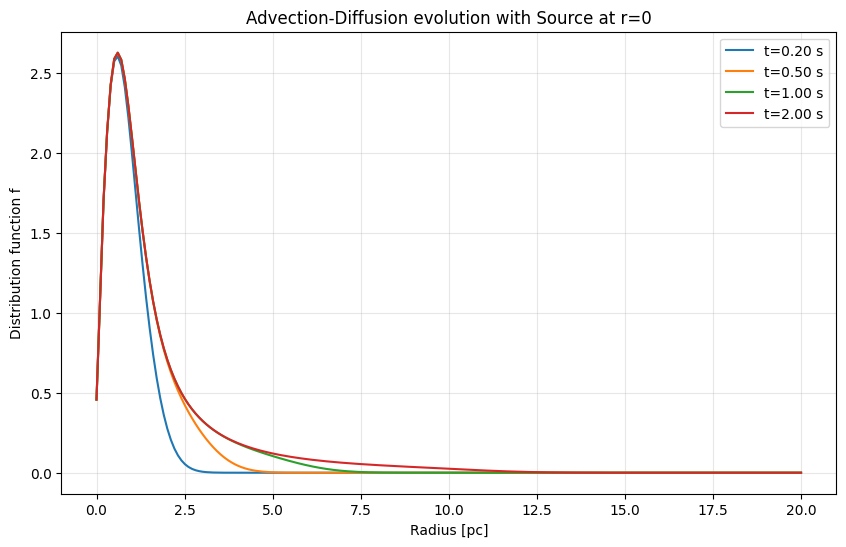

In [ ]:
plt.figure(figsize=(10, 6))

# Advance by chunks and plot
times_to_plot = [20, 50, 100, 200]
current_step = 0

for next_step in times_to_plot:
    solver.step(next_step - current_step)
    current_step = next_step
    plt.plot(grid.r_centers, state.get_f(), label=f't={state.t:.2f} s')

plt.xlabel('Radius [pc]')
plt.ylabel('Distribution function f')
plt.title('Advection-Diffusion evolution with Source at r=0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Understanding the Results

What are we seeing here?
- The **Source** is continuously pumping particles at the center. 
- **Diffusion** pushes them outwards from the high-density center.
- **Advection** (the wind) also carries them outwards at a speed $v_0$.

Over time, the profile starts to reach a **steady state** where the injection from the source is balanced by the transport out of the domain boundary.

## Summary

In this tutorial series, you have gone from zero to running a complete astrophysical transport simulation! 
1. You mastered **Grids** and **States**.
2. You learned how to use the **Solver**.
3. You combined multiple **operators** and **sources**.

You are now ready to explore more advanced cases in the **Examples** section!